In [5]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict,Literal

In [6]:
class QuadState(TypedDict):
    a: int
    b: int
    c: int

    equation: str
    discriminant: float
    roots: str

In [16]:
def show_equation(state:QuadState):
    eq = f"{state['a']}x2 + {state['b']}x + {state['c']}"
    return {'equation': eq}

def calc_discriminant(state:QuadState):
    dis = state['b']**2 - (4*state['a']*state['c'])
    return {'discriminant': dis}

def two_roots(state:QuadState):
    root1 = (-state["b"] + state["discriminant"]**0.5)/(2*state["a"])
    root2 = (-state["b"] - state["discriminant"]**0.5)/(2*state["a"])

    result = f'The roots are {root1} and {root2}'

    return {'roots': result}

def repeated_roots(state: QuadState):

    root = (-state["b"])/(2*state["a"])

    result = f'Only repeating root is {root}'

    return {'roots': result}

def no_roots(state: QuadState):

    result = f'No real roots'

    return {'roots': result}

def check_condition(state:QuadState) -> Literal['two_real_roots', 'repeated_real_roots', 'no_real_roots']:
    if state['discriminant'] > 0:
        return 'two_real_roots'
    elif state['discriminant'] == 0 :
        return 'repeated_real_roots'
    else:
        return 'no_real_roots'

In [17]:
graph = StateGraph(QuadState)

graph.add_node('show equation', show_equation)
graph.add_node('calculate_discriminant',calc_discriminant)
graph.add_node('two_real_roots',two_roots)
graph.add_node('repeated_real_roots',repeated_roots)
graph.add_node('no_real_roots', no_roots)

graph.add_edge(START,'show equation')
graph.add_edge('show equation', 'calculate_discriminant')

graph.add_conditional_edges('calculate_discriminant',check_condition)

graph.add_edge('two_real_roots',END)
graph.add_edge('repeated_real_roots',END)
graph.add_edge('no_real_roots',END)

workflow = graph.compile()


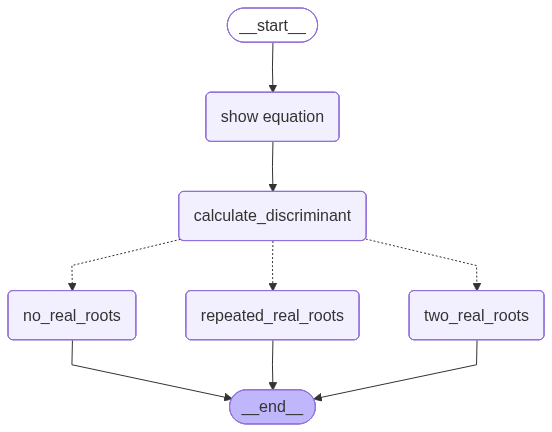

In [14]:
workflow

In [18]:
initial_state = {
    'a': 2, 
    'b': 4,
    'c': 2
}

workflow.invoke(initial_state)

{'a': 2,
 'b': 4,
 'c': 2,
 'equation': '2x2 + 4x + 2',
 'discriminant': 0,
 'roots': 'Only repeating root is -1.0'}